Ultralytics version: 8.4.68
Tue Jun 16 08:32:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             34W /   70W |     801MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

Saving 2f05ad707b994c46b1afec2612cfb81d.jpg to 2f05ad707b994c46b1afec2612cfb81d (1).jpg

image 1/1 /content/2f05ad707b994c46b1afec2612cfb81d (1).jpg: 864x1280 8 Dianthuss, 15.7ms
Speed: 7.7ms preprocess, 15.7ms inference, 0.5ms postprocess per image at shape (1, 3, 864, 1280)
Results saved to /content/runs/detect/predict


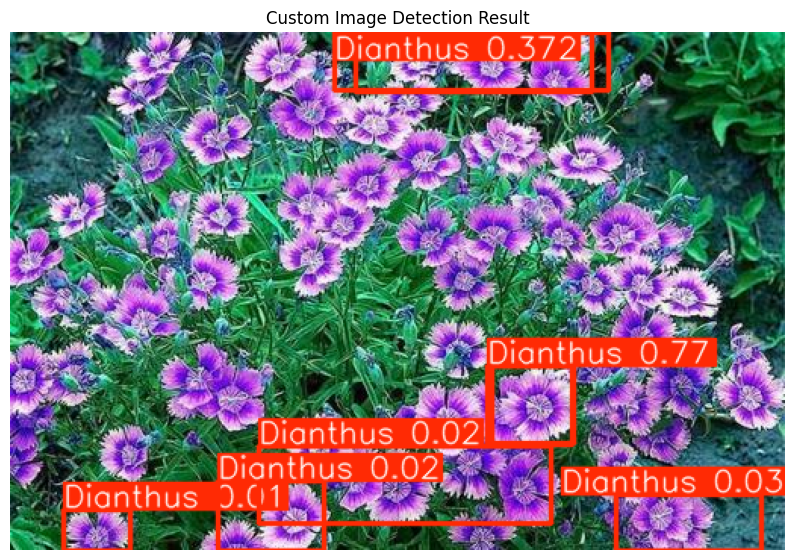

In [5]:
import os
import time
import glob
import random
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from roboflow import Roboflow
from ultralytics import YOLO

import ultralytics
print("Ultralytics version:", ultralytics.__version__)

try:
    !nvidia-smi
except:
    print("GPU check skipped.")

# --- Roboflow Setup ---
rf = Roboflow(api_key="2F5u9omuBLpfomSqXUes")
project = rf.workspace("meow-v4hbw").project("flower-xx3zc")
version = project.version(1)
dataset = version.download("yolov8")

dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml path:", data_yaml_path)

if not os.path.exists(data_yaml_path):
    raise FileNotFoundError("data.yaml was not found.")

train_images = glob.glob(os.path.join(dataset_path, "train", "images", "*"))
valid_images = glob.glob(os.path.join(dataset_path, "valid", "images", "*"))
test_images = glob.glob(os.path.join(dataset_path, "test", "images", "*"))

# --- Training ---
model = YOLO("yolov10n.pt")

train_results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    name="flower_yolov10n_edge",
    patience=20,
    exist_ok=False
)

# --- Load Best Model ---
train_folders = glob.glob("/content/runs/detect/flower_yolov10n_edge*")
latest_train_folder = max(train_folders, key=os.path.getctime)
best_model_path = os.path.join(latest_train_folder, "weights", "best.pt")
trained_model = YOLO(best_model_path)

# --- Prediction on Dataset Image ---
candidate_images = valid_images if valid_images else test_images
sample_dataset_image = random.choice(candidate_images)

dataset_results = trained_model.predict(
    source=sample_dataset_image,
    conf=0.01,
    imgsz=1280,
    max_det=1000,
    save=True
)

# --- Prediction on Custom Uploaded Image ---
uploaded = files.upload()
if uploaded:
    custom_image_path = list(uploaded.keys())[0]
    custom_results = trained_model.predict(
        source=custom_image_path,
        conf=0.01,
        imgsz=1280,
        max_det=1000,
        save=True
    )

    custom_result = custom_results[0]
    plt.figure(figsize=(10, 10))
    plt.imshow(custom_result.plot())
    plt.axis("off")
    plt.title("Custom Image Detection Result")
    plt.show()

In [2]:
from google.colab import files
import os
import glob

train_folders = glob.glob("/content/runs/detect/flower_yolov10n_edge*")
latest_train_folder = max(train_folders, key=os.path.getctime)

results_path = os.path.join(latest_train_folder, "results.png")
weights_path = os.path.join(latest_train_folder, "weights", "best.pt")

print("Latest folder:", latest_train_folder)
print("Results path:", results_path)
print("Weights path:", weights_path)

files.download(results_path)
files.download(weights_path)

Latest folder: /content/runs/detect/flower_yolov10n_edge
Results path: /content/runs/detect/flower_yolov10n_edge/results.png
Weights path: /content/runs/detect/flower_yolov10n_edge/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
import os
import glob

predict_folders = glob.glob("/content/runs/detect/predict*")

if not predict_folders:
    print("No prediction folders found. This usually happens if 'save=False' was used in the model.predict() calls.")
    print("Please ensure 'save=True' is set in your predict calls if you wish to save and download predicted images.")
else:
    latest_predict_folder = max(predict_folders, key=os.path.getctime)

    predicted_images = glob.glob(os.path.join(latest_predict_folder, "*"))

    print("Latest predict folder:", latest_predict_folder)
    print("Predicted images:", predicted_images)

    for img_path in predicted_images:
        files.download(img_path)

Latest predict folder: /content/runs/detect/predict
Predicted images: ['/content/runs/detect/predict/IMG_5083_jpeg.rf.b6c90ad5c1e8236f1227bd23ab75cb51.jpg', '/content/runs/detect/predict/2f05ad707b994c46b1afec2612cfb81d (1).jpg']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>